## Feature Importance   --  Classification 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler
import pickle
from sklearn.model_selection import train_test_split

# algorithms
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [13]:
# functions 
def feature_importance(model):
    # get important features from the model 
    feature_ranks = model.feature_importances_
    # print(feature_ranks)
    # important features 
    for feature, score in zip(indep_x.columns, feature_ranks):
        print(f"{feature} : {score}")
    important_features = indep_x.columns[feature_ranks>0.0]   # thershold for CKD dataset (trail)
    return important_features, feature_ranks

    
# tran test split and standardization 
def split_scaler(indep_x,dep_y):
    x_train,x_test,y_train,y_test = train_test_split(indep_x,dep_y,test_size=0.20,random_state=0)
    # standardization
    sc=StandardScaler()
    x_train=sc.fit_transform(x_train)
    x_test=sc.transform(x_test)
    return  x_train,x_test,y_train,y_test

# model prediction & evaluation 
def cm_pred_eval(classifier,x_test):
    # prediction
    y_pred=classifier.predict(x_test)
    # confusion matrix
    from sklearn.metrics import confusion_matrix
    cm=confusion_matrix(y_test,y_pred)
    # classification report 
    from sklearn.metrics import classification_report
    classi_report=classification_report(y_test,y_pred)
    # accuracy 
    from sklearn.metrics import accuracy_score
    accuracy=accuracy_score(y_test,y_pred)
    return classifier,accuracy,cm,classi_report,x_test,y_test

### --------------- classification algortihms -----------------------------
# decision tree
def decision_tree(x_train,y_train,x_test):
     # model creation 
    from sklearn.tree import DecisionTreeClassifier
    classifier=DecisionTreeClassifier(criterion='entropy',random_state=0)
    classifier.fit(x_train,y_train)
    # model prediction & evaluation
    classifier,accuracy,cm,classi_report,x_test,y_test = cm_pred_eval(classifier,x_test)
    return classifier,accuracy,cm,classi_report,x_test,y_test

# random forest
def random_forest(x_train,y_train,x_test):
     # model creation 
    from sklearn.ensemble import RandomForestClassifier
    classifier=RandomForestClassifier(n_estimators=10,criterion='entropy',random_state=0)
    classifier.fit(x_train,y_train)
    # model prediction & evaluation
    classifier,accuracy,cm,classi_report,x_test,y_test = cm_pred_eval(classifier,x_test)
    return classifier,accuracy,cm,classi_report,x_test,y_test


In [3]:
data_original = pd.read_csv('preprocessed_CKD.csv')
data_ckd= data_original
data_ckd

data_ckd=pd.get_dummies(data_ckd,drop_first=True,dtype=int)
data_ckd.head()

# ip op split 
indep_x=data_ckd.drop('classification_notckd',axis=1)
dep_y = data_ckd['classification_notckd']


## Train Random Forest - Extract feature importance - Plot graph - Remove low importance features - Retrain model - Compare accuracy

In [4]:
# train test split
x_train, x_test, y_train, y_test = split_scaler(indep_x,dep_y)
# model creation - with original features 
classifier,accuracy,cm,classi_report,x_test,y_test = random_forest(x_train,y_train,x_test)
rf_acc_before = accuracy
print('accuracy before feature importance: ' , rf_acc_before)

# get important features from the model 
feature_ranks = classifier.feature_importances_
# print(feature_ranks)
# important features 
for feature, score in zip(indep_x.columns, feature_ranks):
    print(f"{feature} : {score}")


accuracy before feature importance:  1.0
age : 0.004002390820687258
bp : 0.0017344795998737923
sg : 0.08152733861270929
al : 0.06183936068394302
su : 0.00605306078541981
bgr : 0.02026904773431248
bu : 0.004717762645048302
sc : 0.03773643331167263
sod : 0.01568518128096062
pot : 0.0035409114329213814
hemo : 0.08580806359648745
pcv : 0.2401975538267574
wc : 0.050186951427323837
rc : 0.1766014245968088
rbc_normal : 0.04876577820693549
rbc_unknown : 0.03524568201583038
pc_normal : 0.005485506446429421
pc_unknown : 0.02060070986413496
pcc_present : 0.0024548307469380902
pcc_unknown : 0.0006979561902115293
ba_present : 0.0
ba_unknown : 0.0
htn_unknown : 0.0
htn_yes : 0.04208452041194552
dm_unknown : 0.0
dm_yes : 0.043527685388022694
cad_unknown : 0.0
cad_yes : 0.0
appet_poor : 0.010008162849067047
appet_unknown : 0.0
pe_unknown : 0.0
pe_yes : 0.0012292075255588152
ane_unknown : 0.0
ane_yes : 0.0


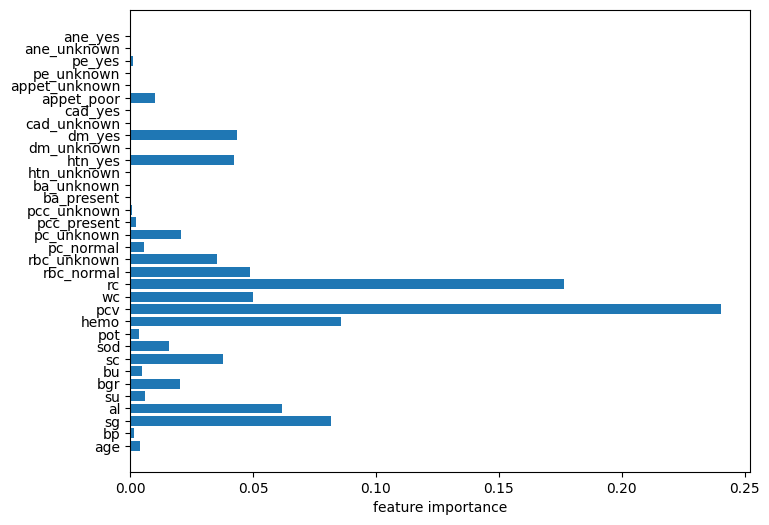

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6)) 
plt.barh(indep_x.columns, feature_ranks)
plt.xlabel('feature importance')
plt.show()

In [6]:
# removing least important features 
new_indep_x = indep_x.drop(['ba_present','ba_unknown','htn_unknown','dm_unknown',
                            'cad_unknown','cad_yes','appet_unknown','pe_unknown',
                            'ane_unknown','ane_yes'],axis=1)

In [7]:
new_indep_x.columns

Index(['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo',
       'pcv', 'wc', 'rc', 'rbc_normal', 'rbc_unknown', 'pc_normal',
       'pc_unknown', 'pcc_present', 'pcc_unknown', 'htn_yes', 'dm_yes',
       'appet_poor', 'pe_yes'],
      dtype='object')

In [8]:
# train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = split_scaler(new_indep_x,dep_y)
# model creation - with original features 
classifier,accuracy,cm,classi_report,x_test,y_test = random_forest(x_train,y_train,x_test)
rf_acc_after = accuracy
print('accuracy After feature importance: ' , rf_acc_before)

accuracy After feature importance:  1.0


## Train decision tree - Extract feature importance - Plot graph - Remove low importance features - Retrain model - Compare accuracy

In [14]:
# train test split
x_train, x_test, y_train, y_test = split_scaler(indep_x,dep_y)
# model creation - with original features 
classifier,accuracy,cm,classi_report,x_test,y_test = decision_tree(x_train,y_train,x_test)
dt_acc_before = accuracy
print('accuracy before feature importance - decision_tree: ' , dt_acc_before)

important_features, feature_ranks = feature_importance(classifier)
important_features

accuracy before feature importance - decision_tree:  1.0
age : 0.0
bp : 0.0
sg : 0.18272141675167983
al : 0.08797413895905996
su : 0.0
bgr : 0.0
bu : 0.0
sc : 0.05510905599658619
sod : 0.01349731051817212
pot : 0.0
hemo : 0.6268207218949046
pcv : 0.0
wc : 0.0
rc : 0.0
rbc_normal : 0.03387735587959732
rbc_unknown : 0.0
pc_normal : 0.0
pc_unknown : 0.0
pcc_present : 0.0
pcc_unknown : 0.0
ba_present : 0.0
ba_unknown : 0.0
htn_unknown : 0.0
htn_yes : 0.0
dm_unknown : 0.0
dm_yes : 0.0
cad_unknown : 0.0
cad_yes : 0.0
appet_poor : 0.0
appet_unknown : 0.0
pe_unknown : 0.0
pe_yes : 0.0
ane_unknown : 0.0
ane_yes : 0.0


Index(['sg', 'al', 'sc', 'sod', 'hemo', 'rbc_normal'], dtype='object')

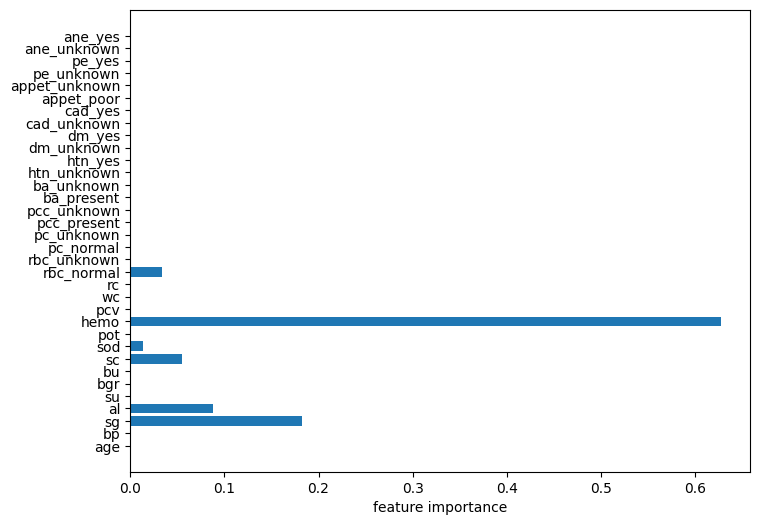

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6)) 
plt.barh(indep_x.columns, feature_ranks)
plt.xlabel('feature importance')
plt.show()

In [17]:
# removing least important features 
new_indep_x_DT = indep_x[important_features]

In [18]:
new_indep_x_DT.columns

Index(['sg', 'al', 'sc', 'sod', 'hemo', 'rbc_normal'], dtype='object')

In [19]:
# train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = split_scaler(new_indep_x,dep_y)
# model creation - with original features 
classifier,accuracy,cm,classi_report,x_test,y_test = decision_tree(x_train,y_train,x_test)
dt_acc_after = accuracy
print('accuracy After feature importance: ' , dt_acc_after)

accuracy After feature importance:  1.0


## dataframe for comparision 

In [20]:
df = pd.DataFrame(index=['accuracy'],columns=['rf_before_feature_impo','rf_features_count','rf_after_feature_impo',
                                              'DT_before_feature_impo','DT_features_count','DT_after_feature_impo'])
df['rf_before_feature_impo']=rf_acc_before
df['rf_features_count']=len(new_indep_x.columns)
df['rf_after_feature_impo']=rf_acc_after
df['DT_before_feature_impo']=dt_acc_before
df['DT_features_count']=len(new_indep_x_DT.columns)
df['DT_after_feature_impo']=dt_acc_after
df

,rf_before_feature_impo,rf_features_count,rf_after_feature_impo,DT_before_feature_impo,DT_features_count,DT_after_feature_impo
accuracy,1.0,24,1.0,1.0,6,1.0
